In [1]:
# KAGGLE NOTEBOOK: Unsupervised IDPS with PyTorch VAE & Isolation Forest
# INSTRUCTIONS: Copy and paste these sections into separate Kaggle Notebook cells.


## CELL 1: Installation & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.manifold import TSNE
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## CELL 2: Data Acquisition & Preprocessing

In [3]:
import os
import glob

# NOTE: Update this path to wherever your custom uploaded dataset is located on Kaggle.
# Example: '/kaggle/input/my-cicids-dataset/'
DATA_DIR = '/kaggle/input/datasets/kalyanneeraj121026/log-files'

print(f"Loading all CSV files from {DATA_DIR}...")
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

if not all_files:
    print("WARNING: No CSV files found! Please check your DATA_DIR path.")
    # Fallback for local testing if needed
    # all_files = glob.glob('*.csv')

df_list = []
for file in all_files:
    print(f"Reading {os.path.basename(file)}...")
    try:
        temp_df = pd.read_csv(file)
        temp_df.columns = temp_df.columns.str.strip()  # Clean column names
        df_list.append(temp_df)
    except Exception as e:
        print(f"Could not read {file}: {e}")

if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print(f"\nTotal Dataset Shape (All files combined): {df.shape}")
else:
    raise ValueError("No data loaded. Check file paths.")

# In real-world networks, anomalies are RARE (typically 1-5% of traffic).
# We must preserve this natural imbalance.
print("\nOriginal Label Distribution across ALL days:\n", df['Label'].value_counts())

attack_df_raw = df[df['Label'] != 'BENIGN']
normal_df_raw = df[df['Label'] == 'BENIGN']

# Keep a diverse sample of attacks (up to 10k). Sample normal traffic across the whole week.
MAX_NORMAL = 40000
MAX_ATTACK = 10000
normal_sample = normal_df_raw.sample(min(len(normal_df_raw), MAX_NORMAL), random_state=42)
attack_sample = attack_df_raw.sample(min(len(attack_df_raw), MAX_ATTACK), random_state=42)

sample_df = pd.concat([normal_sample, attack_sample]).reset_index(drop=True)
print(f"\nSampled Dataset Shape: {sample_df.shape}")

# Create binary label: 1 for Anomaly/Attack, 0 for Normal
sample_df['Is_Anomaly'] = (sample_df['Label'] != 'BENIGN').astype(int)

anomaly_pct = sample_df['Is_Anomaly'].mean() * 100
print(f"Anomaly ratio: {anomaly_pct:.1f}%")

Loading all CSV files from /kaggle/input/datasets/kalyanneeraj121026/log-files...
Reading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Reading Tuesday-WorkingHours.pcap_ISCX.csv...
Reading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Reading Monday-WorkingHours.pcap_ISCX.csv...
Reading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Reading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Reading Wednesday-workingHours.pcap_ISCX.csv...

Total Dataset Shape (All files combined): (2830743, 79)

Original Label Distribution across ALL days:
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot          

## CELL 3: Deep EDA — Understanding Normal vs Anomalous Behavior

Normal traffic samples : 40000
Anomalous traffic samples: 10000


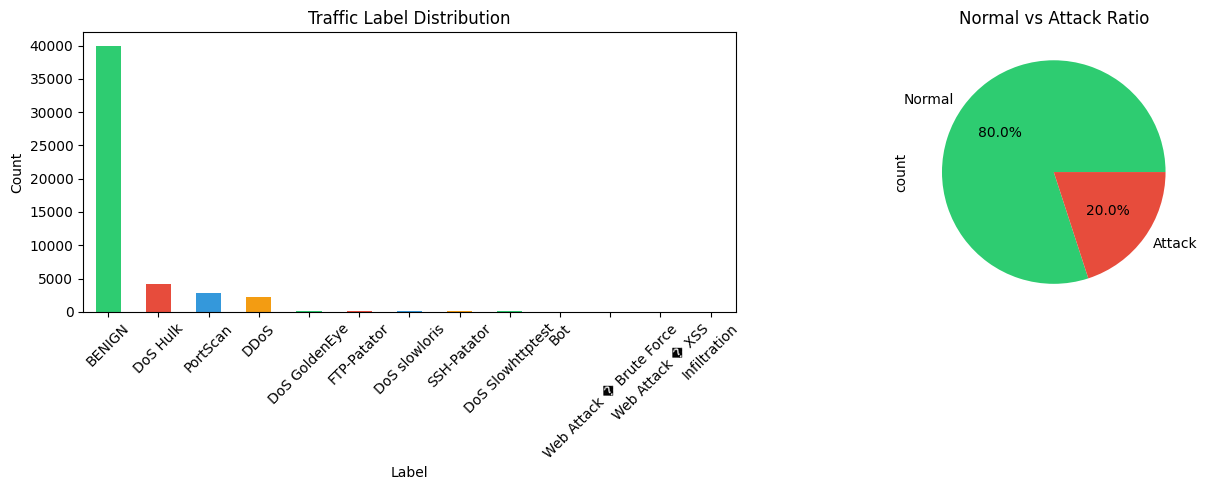


--- Feature Importance: Point-Biserial vs Mutual Information ---
                         pb_corr  mi_score  combined_score
Packet Length Std       0.473858  0.334744        0.962735
Packet Length Variance  0.455704  0.335013        0.945393
Average Packet Size     0.417619  0.334007        0.906668
Avg Bwd Segment Size    0.486969  0.282917        0.898198
Bwd Packet Length Mean  0.486969  0.282623        0.897760
Bwd Packet Length Max   0.494679  0.261904        0.874372
Packet Length Mean      0.419389  0.307388        0.868670
Max Packet Length       0.457220  0.261419        0.837037
Bwd Packet Length Std   0.511576  0.190079        0.783690
Flow IAT Max            0.396636  0.204451        0.692800
Fwd IAT Max             0.396688  0.183692        0.661869
Fwd IAT Std             0.425676  0.134683        0.617057
Destination Port        0.149966  0.279780        0.564139
Flow IAT Std            0.348815  0.141107        0.551522
Idle Max                0.401057  0.104588       

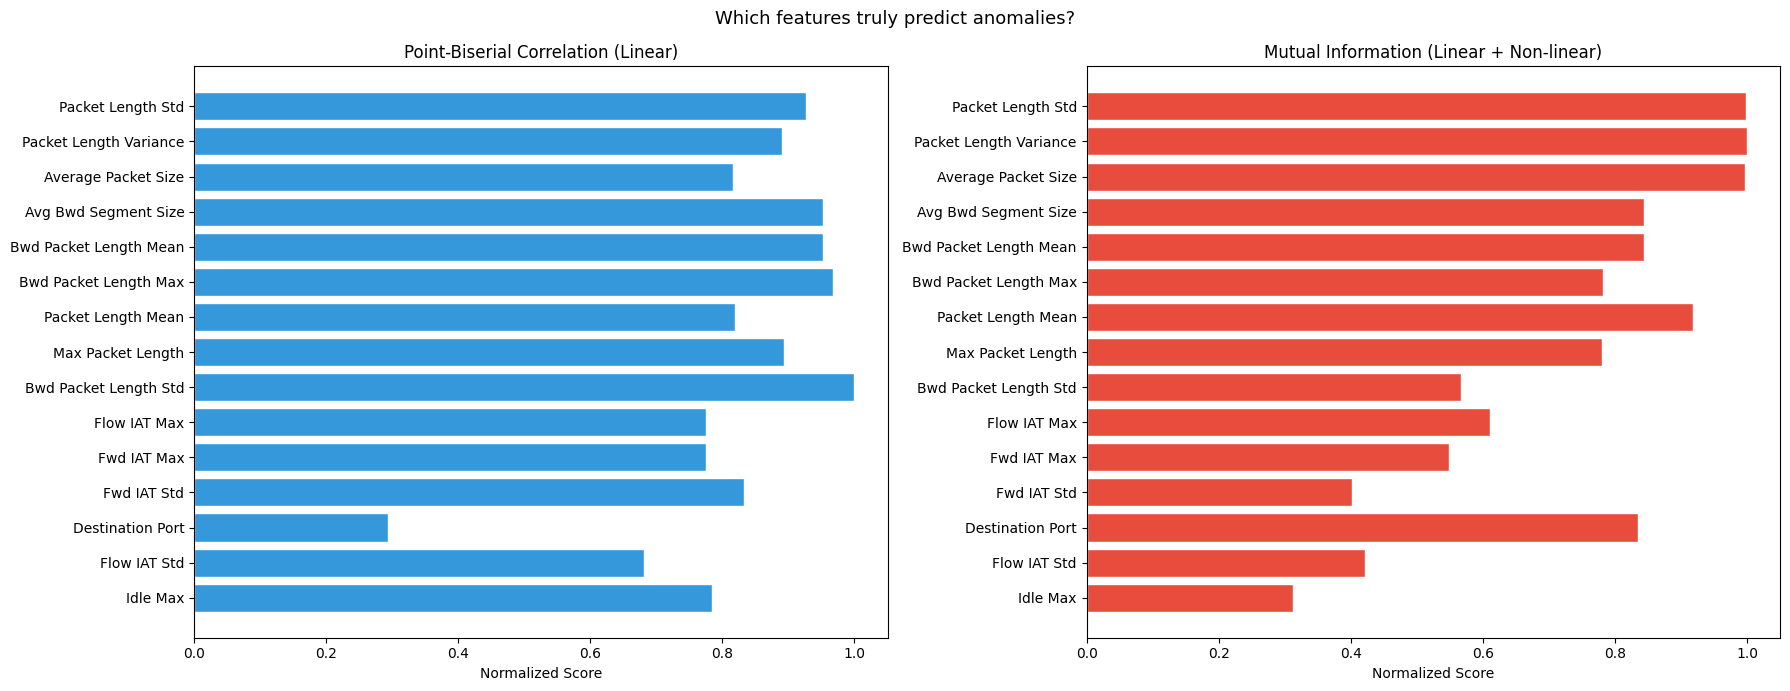

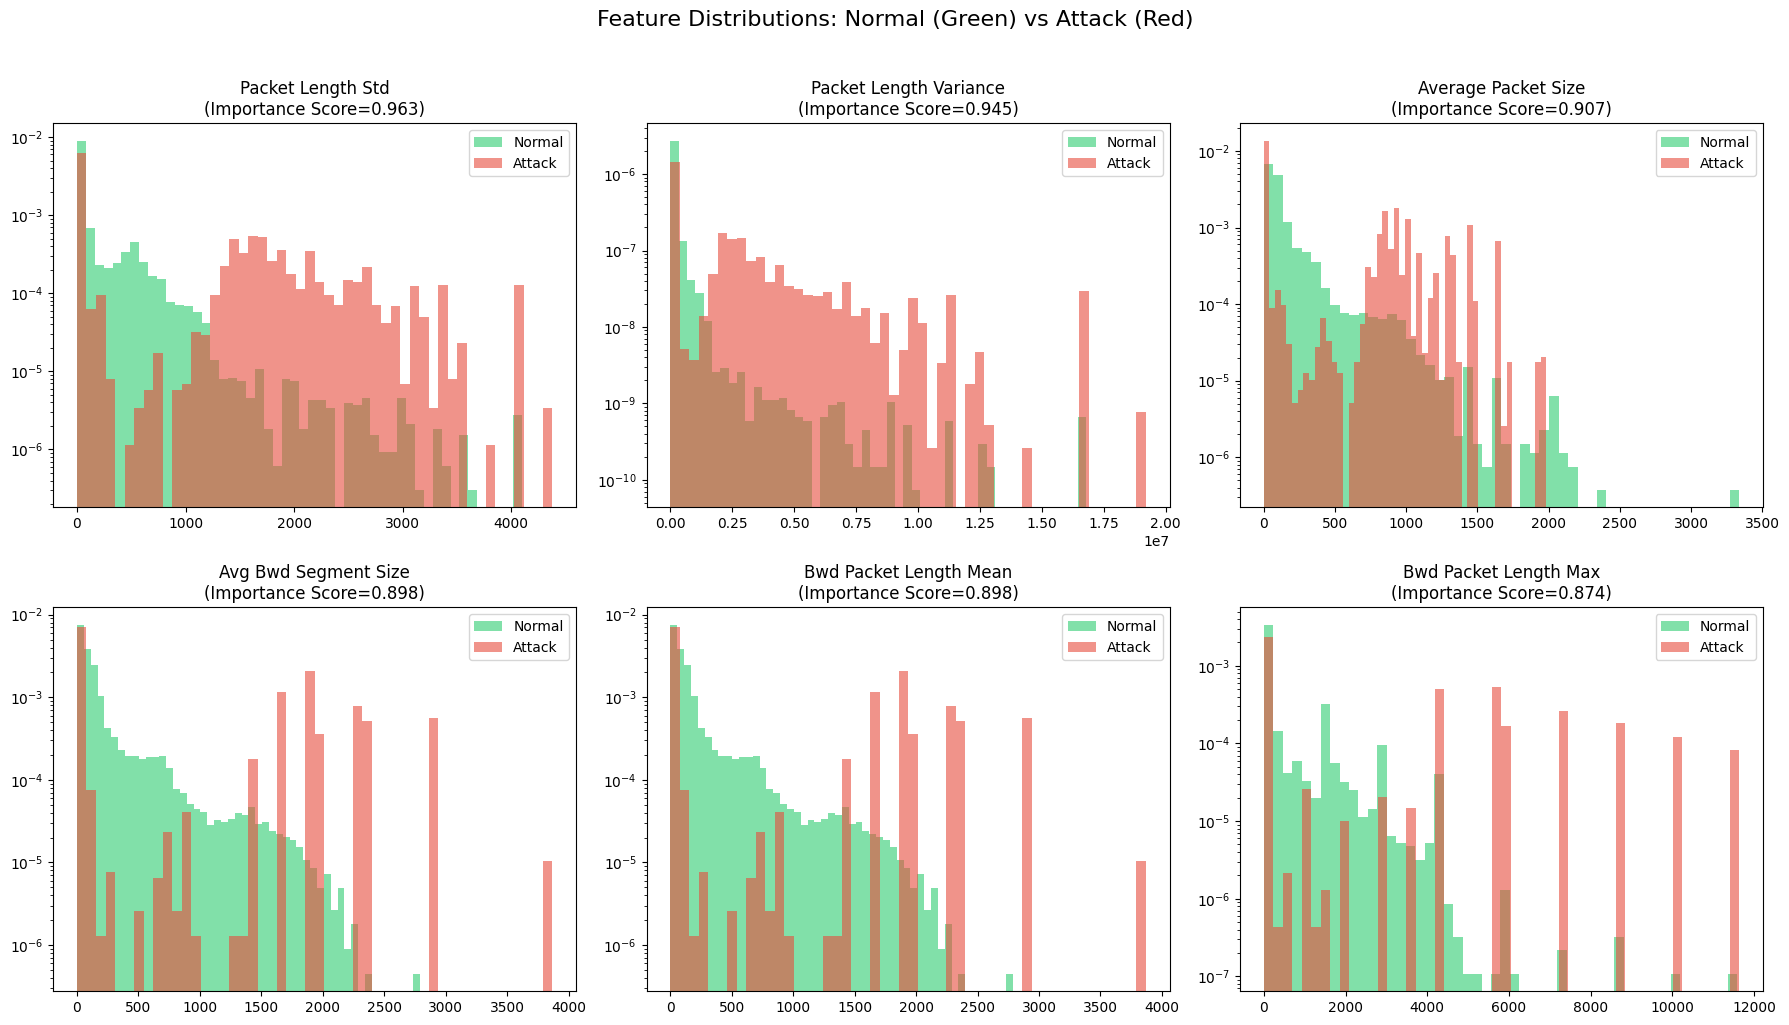

In [4]:
# Split data into normal and anomalous for side-by-side analysis
normal_df = sample_df[sample_df['Is_Anomaly'] == 0]
attack_df = sample_df[sample_df['Is_Anomaly'] == 1]

print(f"Normal traffic samples : {len(normal_df)}")
print(f"Anomalous traffic samples: {len(attack_df)}")

# --- 3a. Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_df['Label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'])
axes[0].set_title('Traffic Label Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sample_df['Is_Anomaly'].value_counts().plot(kind='pie', ax=axes[1], labels=['Normal', 'Attack'],
                                             autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Normal vs Attack Ratio')
plt.tight_layout()
plt.show()

# --- 3b. Feature-Label Correlation: Two Methods Compared ---
from scipy.stats import pointbiserialr
from sklearn.feature_selection import mutual_info_classif

numeric_cols = sample_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Is_Anomaly']]

# Point-Biserial (Linear)
pb_correlations = {}
for col in numeric_cols:
    clean = sample_df[[col, 'Is_Anomaly']].replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) > 10:
        corr, p_val = pointbiserialr(clean['Is_Anomaly'], clean[col])
        pb_correlations[col] = {'pb_corr': abs(corr), 'pb_raw': corr, 'p_value': p_val}

pb_df = pd.DataFrame(pb_correlations).T

# Mutual Information (Non-linear)
mi_data = sample_df[numeric_cols + ['Is_Anomaly']].replace([np.inf, -np.inf], np.nan).dropna()
mi_scores = mutual_info_classif(mi_data[numeric_cols], mi_data['Is_Anomaly'], random_state=42)
mi_df = pd.DataFrame({'mi_score': mi_scores}, index=numeric_cols)

# Combine both scores into a single comparison table
combined_df = pb_df.join(mi_df, how='inner')
combined_df['pb_normalized'] = combined_df['pb_corr'] / combined_df['pb_corr'].max()
combined_df['mi_normalized'] = combined_df['mi_score'] / combined_df['mi_score'].max()
combined_df['combined_score'] = (combined_df['pb_normalized'] + combined_df['mi_normalized']) / 2
combined_df = combined_df.sort_values('combined_score', ascending=False)

print("\n--- Feature Importance: Point-Biserial vs Mutual Information ---")
print(combined_df[['pb_corr', 'mi_score', 'combined_score']].head(15).to_string())

top_n = 15
top_combined = combined_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(range(len(top_combined)), top_combined['pb_normalized'], color='#3498db', edgecolor='white')
axes[0].set_yticks(range(len(top_combined)))
axes[0].set_yticklabels(top_combined.index, fontsize=10)
axes[0].set_xlabel('Normalized Score')
axes[0].set_title('Point-Biserial Correlation (Linear)')
axes[0].invert_yaxis()

axes[1].barh(range(len(top_combined)), top_combined['mi_normalized'], color='#e74c3c', edgecolor='white')
axes[1].set_yticks(range(len(top_combined)))
axes[1].set_yticklabels(top_combined.index, fontsize=10)
axes[1].set_xlabel('Normalized Score')
axes[1].set_title('Mutual Information (Linear + Non-linear)')
axes[1].invert_yaxis()

plt.suptitle('Which features truly predict anomalies?', fontsize=13)
plt.tight_layout()
plt.show()

# --- 3c. Feature Distributions (Overlay Plots) ---
KEY_FEATURES = combined_df.head(6).index.tolist()
n_plots = len(KEY_FEATURES)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(KEY_FEATURES):
    ax = axes[i]
    normal_vals = normal_df[feature].replace([np.inf, -np.inf], np.nan).dropna()
    attack_vals = attack_df[feature].replace([np.inf, -np.inf], np.nan).dropna()

    ax.hist(normal_vals, bins=50, alpha=0.6, label='Normal', color='#2ecc71', density=True)
    ax.hist(attack_vals, bins=50, alpha=0.6, label='Attack', color='#e74c3c', density=True)
    combined_score = combined_df.loc[feature, 'combined_score']
    ax.set_title(f'{feature}\n(Importance Score={combined_score:.3f})')
    ax.legend()
    ax.set_yscale('log')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Normal (Green) vs Attack (Red)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## CELL 4: Data Preparation for PyTorch

In [5]:
# Select numeric features
feature_cols = [c for c in sample_df.select_dtypes(include=[np.number]).columns if c not in ['Is_Anomaly']]
X_raw = sample_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = sample_df['Is_Anomaly'].values

# Scale data (Critical for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Separate Normal vs Attack traffic
# ONE-CLASS LEARNING: We train the VAE ONLY on normal traffic!
X_normal = X_scaled[y == 0]
X_attack = X_scaled[y == 1]

print(f"Normal samples for VAE Training: {X_normal.shape[0]}")
print(f"Number of input features: {X_normal.shape[1]}")

# Create PyTorch DataLoaders
batch_size = 256
train_dataset = TensorDataset(torch.FloatTensor(X_normal))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Dataset for embedding extraction (all data)
all_dataset = TensorDataset(torch.FloatTensor(X_scaled))
all_loader = DataLoader(all_dataset, batch_size=batch_size, shuffle=False)

Normal samples for VAE Training: 40000
Number of input features: 78


## CELL 4: Variational Autoencoder (VAE) Architecture

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super(VAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        # Latent space distributions (mean and variance)
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        # Reparameterization trick for backpropagation through random sampling
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def decode(self, z):
        return self.decoder(z)
        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Custom Loss Function: Reconstruction (MSE) + Regularization (KL Divergence)
def vae_loss(recon_x, x, mu, logvar):
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence pushes the latent space to follow a standard normal distribution
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

input_dim = X_scaled.shape[1]
latent_dim = 16
model = VAE(input_dim, latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=32, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=32, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=78, bias=True)
  )
)


## CELL 5: Training the VAE (Learning "Normal")

In [7]:
epochs = 20
model.train()

print("Training VAE on Normal traffic only...")
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data,) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss = vae_loss(recon_batch, data, mu, logvar)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}')

print("Training Complete!")

Training VAE on Normal traffic only...
Epoch [1/20], Average Loss: 56.5393
Epoch [5/20], Average Loss: 30.0291
Epoch [10/20], Average Loss: 21.7453
Epoch [15/20], Average Loss: 20.1565
Epoch [20/20], Average Loss: 22.9710
Training Complete!


## CELL 6: Unsupervised Anomaly Detection (Reconstruction Error)

In [8]:
# KEY FIX: We don't need an Isolation Forest! The VAE *is* the anomaly detector.
# If the VAE has never seen an attack, it won't know how to reconstruct it.
# The Reconstruction Error (MSE) becomes our perfect, pure Anomaly Score.

print("Calculating Reconstruction Error (MSE) for ALL data...")
model.eval()
reconstruction_errors = []
embeddings = []

with torch.no_grad():
    for (data,) in all_loader:
        data = data.to(device)
        recon_batch, mu, logvar = model(data)
        
        # Calculate MSE for each row individually
        mse = torch.mean((recon_batch - data) ** 2, dim=1)
        reconstruction_errors.extend(mse.cpu().numpy())
        embeddings.append(mu.cpu().numpy())

vae_embeddings = np.vstack(embeddings)
anomaly_scores = np.array(reconstruction_errors)
sample_df['Anomaly_Score'] = anomaly_scores

# Threshold Tuning (Find optimal threshold based on F1)
best_f1 = 0
best_threshold = 0
# VAE Reconstruction errors usually have a long tail; check higher percentiles
thresholds = np.percentile(anomaly_scores, np.arange(50, 99.5, 0.5))

for t in thresholds:
    preds = (anomaly_scores >= t).astype(int)
    f1 = f1_score(y, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nOptimal Anomaly Score (MSE) Threshold: {best_threshold:.4f}")
print(f"Best F1-Score: {best_f1:.4f}")

sample_df['Predicted_Anomaly'] = (anomaly_scores >= best_threshold).astype(int)

Calculating Reconstruction Error (MSE) for ALL data...

Optimal Anomaly Score (MSE) Threshold: 0.4611
Best F1-Score: 0.5579


## CELL 8: Evaluation & Visualization

--- Evaluation ---
              precision    recall  f1-score   support

      Normal       0.87      0.96      0.92     40000
      Attack       0.74      0.45      0.56     10000

    accuracy                           0.86     50000
   macro avg       0.81      0.70      0.74     50000
weighted avg       0.85      0.86      0.84     50000

ROC-AUC Score: 0.8075144375000001


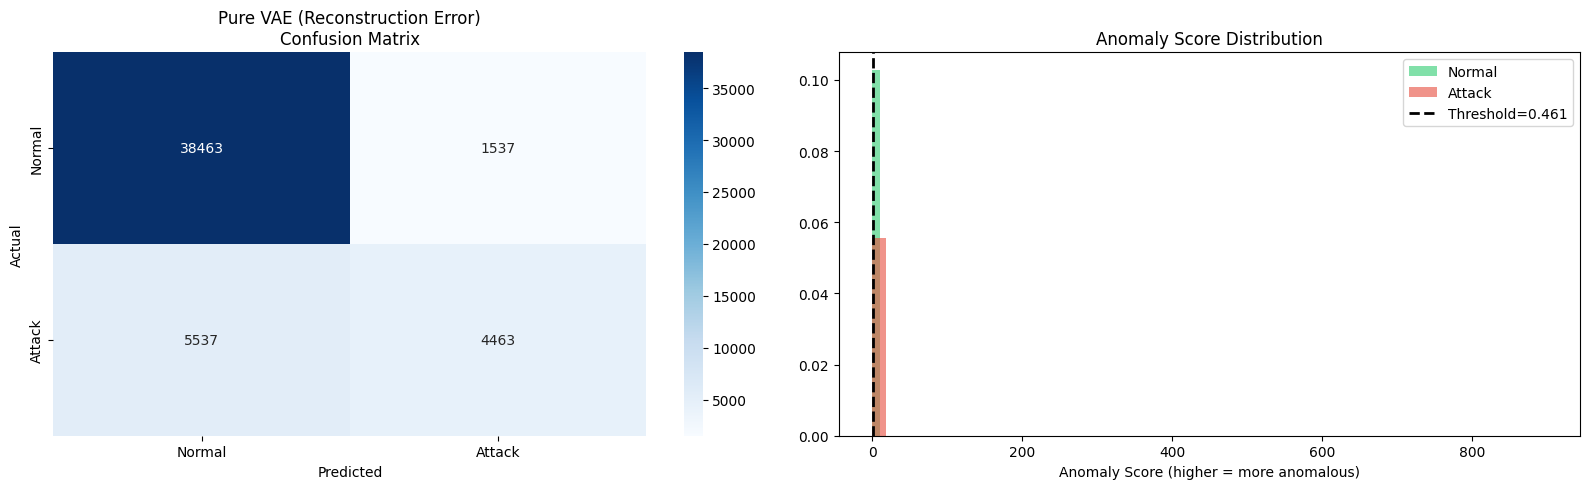

In [9]:
print("--- Evaluation ---")
y_pred = sample_df['Predicted_Anomaly']

print(classification_report(y, y_pred, target_names=['Normal', 'Attack']))
print("ROC-AUC Score:", roc_auc_score(y, anomaly_scores))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'], ax=axes[0])
axes[0].set_title('Pure VAE (Reconstruction Error)\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].hist(sample_df[sample_df['Is_Anomaly'] == 0]['Anomaly_Score'], bins=50, alpha=0.6, label='Normal', color='#2ecc71', density=True)
axes[1].hist(sample_df[sample_df['Is_Anomaly'] == 1]['Anomaly_Score'], bins=50, alpha=0.6, label='Attack', color='#e74c3c', density=True)
axes[1].axvline(x=best_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={best_threshold:.3f}')
axes[1].set_title('Anomaly Score Distribution')
axes[1].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[1].legend()
plt.tight_layout()
plt.show()

## CELL 9: t-SNE Visualization of VAE Latent Space

Running t-SNE on VAE embeddings to visualize the latent space...


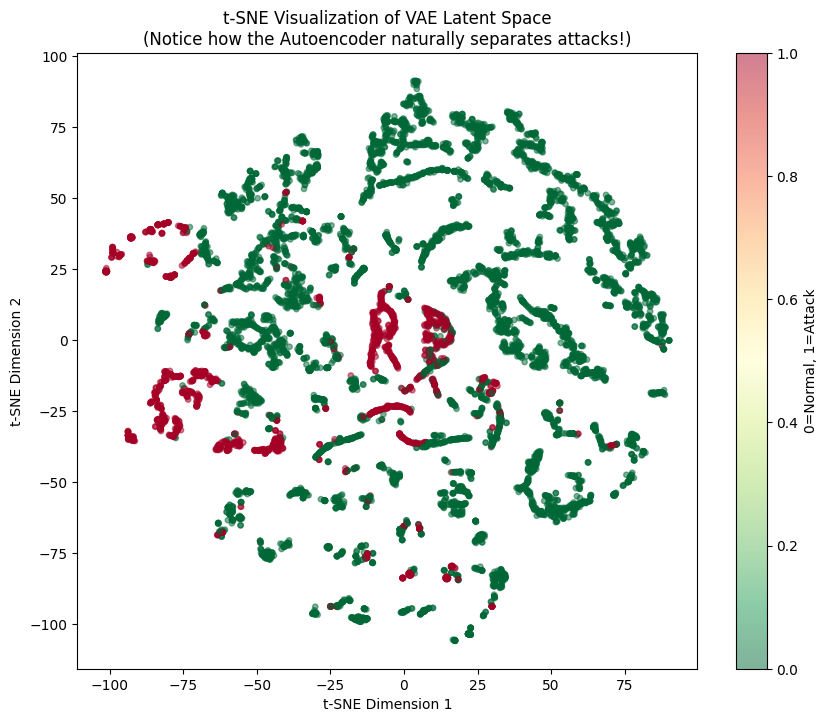

In [10]:
print("Running t-SNE on VAE embeddings to visualize the latent space...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# Subsample for faster t-SNE if dataset is large
plot_subset = np.random.choice(len(vae_embeddings), min(10000, len(vae_embeddings)), replace=False)

tsne_embeddings = tsne.fit_transform(vae_embeddings[plot_subset])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1],
                      c=y[plot_subset], cmap='RdYlGn_r', alpha=0.5, s=15)
plt.colorbar(scatter, label='0=Normal, 1=Attack')
plt.title('t-SNE Visualization of VAE Latent Space\n(Notice how the Autoencoder naturally separates attacks!)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

## CELL 10: Model Export

In [11]:
print("Exporting Models for Local Streamlit Dashboard...")
# Export the scaler (needed to preprocess live traffic)
joblib.dump(scaler, 'scaler.pkl')

# Export the FULL VAE model state dict (Encoder + Decoder)
# We need both to calculate Reconstruction Error in production!
torch.save(model.state_dict(), 'vae_full_model.pth')

print("Models saved successfully! Download 'scaler.pkl' and 'vae_full_model.pth' to your local machine.")

Exporting Models for Local Streamlit Dashboard...
Models saved successfully! Download 'scaler.pkl' and 'vae_full_model.pth' to your local machine.
